# 06. PyTorch Transfer Learning Exercises

Welcome to the 06. PyTorch Transfer Learning exercise template notebook.

There are several questions in this notebook and it's your goal to answer them by writing Python and PyTorch code.

> **Note:** There may be more than one solution to each of the exercises, don't worry too much about the *exact* right answer. Try to write some code that works first and then improve it if you can.

## Resources and solutions

* These exercises/solutions are based on [section 06. PyTorch Transfer Learning](https://www.learnpytorch.io/06_pytorch_transfer_learning/) of the Learn PyTorch for Deep Learning course by Zero to Mastery.

**Solutions:**

Try to complete the code below *before* looking at these.

* See a live [walkthrough of the solutions (errors and all) on YouTube](https://youtu.be/ueLolShyFqs).
* See an example [solutions notebook for these exercises on GitHub](https://github.com/mrdbourke/pytorch-deep-learning/blob/main/extras/solutions/06_pytorch_transfer_learning_exercise_solutions.ipynb).

## 1. Make predictions on the entire test dataset and plot a confusion matrix for the results of our model compared to the truth labels.
* **Note:** You will need to get the dataset and the trained model/retrain the model from notebook 06 to perform predictions.
* Check out [03. PyTorch Computer Vision section 10](https://www.learnpytorch.io/03_pytorch_computer_vision/#10-making-a-confusion-matrix-for-further-prediction-evaluation) for ideas.

In [11]:
# Import required libraries/code
import torch
import torchvision
import numpy as np
import matplotlib.pyplot as plt

from torch import nn
from torchvision import transforms, datasets

# Try to get torchinfo, install it if it doesn't work
try:
    from torchinfo import summary
except:
    print("[INFO] Couldn't find torchinfo... installing it.")
    !pip install -q torchinfo
    from torchinfo import summary

# Try to import the going_modular directory, download it from GitHub if it doesn't work
try:
    from going_modular.going_modular import data_setup, engine
except:
    # Get the going_modular scripts
    print("[INFO] Couldn't find going_modular scripts... downloading them from GitHub.")
    !git clone https://github.com/mrdbourke/pytorch-deep-learning
    !mv pytorch-deep-learning/going_modular .
    !rm -rf pytorch-deep-learning
    from going_modular.going_modular import data_setup, engine

[INFO] Couldn't find torchinfo... installing it.
[INFO] Couldn't find going_modular scripts... downloading them from GitHub.
Cloning into 'pytorch-deep-learning'...
remote: Enumerating objects: 4393, done.
remote: Total 4393 (delta 0), reused 0 (delta 0), pack-reused 4393 (from 1)
Receiving objects: 100% (4393/4393), 764.14 MiB | 15.83 MiB/s, done.
Resolving deltas: 100% (2657/2657), done.
Updating files: 100% (248/248), done.


In [12]:
# Setup device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

### Get data

In [13]:
import os
import requests
import zipfile

from pathlib import Path

# Setup path to data folder
data_path = Path("data/")
image_path = data_path / "pizza_steak_sushi"

# If the image folder doesn't exist, download it and prepare it...
if image_path.is_dir():
    print(f"{image_path} directory exists.")
else:
    print(f"Did not find {image_path} directory, creating one...")
    image_path.mkdir(parents=True, exist_ok=True)

    # Download pizza, steak, sushi data
    with open(data_path / "pizza_steak_sushi.zip", "wb") as f:
        request = requests.get("https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip")
        print("Downloading pizza, steak, sushi data...")
        f.write(request.content)

    # Unzip pizza, steak, sushi data
    with zipfile.ZipFile(data_path / "pizza_steak_sushi.zip", "r") as zip_ref:
        print("Unzipping pizza, steak, sushi data...")
        zip_ref.extractall(image_path)

    # Remove .zip file
    os.remove(data_path / "pizza_steak_sushi.zip")

# Setup Dirs
train_dir = image_path / "train"
test_dir = image_path / "test"

Did not find data/pizza_steak_sushi directory, creating one...
Unzipping pizza, steak, sushi data...


### Prepare data

In [14]:
# Create a transforms pipeline
simple_transform = transforms.Compose([
    transforms.Resize((224, 224)), # 1. Reshape all images to 224x224 (though some models may require different sizes)
    transforms.ToTensor(), # 2. Turn image values to between 0 & 1
    transforms.Normalize(mean=[0.485, 0.456, 0.406], # 3. A mean of [0.485, 0.456, 0.406] (across each colour channel)
                         std=[0.229, 0.224, 0.225]) # 4. A standard deviation of [0.229, 0.224, 0.225] (across each colour channel),
])

In [15]:
# Create training and testing DataLoader's as well as get a list of class names
train_dataloader, test_dataloader, class_names = data_setup.create_dataloaders(train_dir=train_dir,
                                                                               test_dir=test_dir,
                                                                               transform=simple_transform, # resize, convert images to between 0 & 1 and normalize them
                                                                               batch_size=32) # set mini-batch size to 32

train_dataloader, test_dataloader, class_names

(<torch.utils.data.dataloader.DataLoader at 0x7d4c6916e590>,
 ['pizza', 'steak', 'sushi'])

### Get and prepare a pretrained model

In [16]:
# Setup the model with pretrained weights and send it to the target device
model_0 = torchvision.models.efficientnet_b0(pretrained=True).to(device)
#model_0 # uncomment to output (it's very long)

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth
100%|██████████| 20.5M/20.5M [00:00<00:00, 115MB/s]


In [17]:
# Freeze all base layers in the "features" section of the model (the feature extractor) by setting requires_grad=False
for param in model_0.features.parameters():
    param.requires_grad = False

In [18]:
# Set the manual seeds
torch.manual_seed(42)
torch.cuda.manual_seed(42)

# Get the length of class_names (one output unit for each class)
output_shape = len(class_names)

# Recreate the classifier layer and seed it to the target device
model_0.classifier = torch.nn.Sequential(
    torch.nn.Dropout(p=0.2, inplace=True),
    torch.nn.Linear(in_features=1280,
                    out_features=output_shape, # same number of output units as our number of classes
                    bias=True)).to(device)

### Train model

In [19]:
# Define loss and optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_0.parameters(), lr=0.001)

In [61]:
# Set the random seeds
torch.manual_seed(42)
torch.cuda.manual_seed(42)

# Start the timer
from timeit import default_timer as timer
start_time = timer()

# Setup training and save the results
model_0_results = engine.train(model=model_0,
                       train_dataloader=train_dataloader,
                       test_dataloader=test_dataloader,
                       optimizer=optimizer,
                       loss_fn=loss_fn,
                       epochs=5,
                       device=device)

# End the timer and print out how long it took
end_time = timer()
print(f"[INFO] Total training time: {end_time-start_time:.3f} seconds")

  0%|          | 0/5 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 1.1222 | train_acc: 0.3477 | test_loss: 1.0928 | test_acc: 0.3400
Epoch: 2 | train_loss: 1.1290 | train_acc: 0.2930 | test_loss: 1.0883 | test_acc: 0.3911
Epoch: 3 | train_loss: 1.1166 | train_acc: 0.2656 | test_loss: 1.0937 | test_acc: 0.3097
Epoch: 4 | train_loss: 1.1160 | train_acc: 0.2734 | test_loss: 1.0965 | test_acc: 0.2992
Epoch: 5 | train_loss: 1.1286 | train_acc: 0.2812 | test_loss: 1.1013 | test_acc: 0.2784
[INFO] Total training time: 9.265 seconds


In [21]:
# Import tqdm for progress bar
from tqdm.auto import tqdm

# 1. Make predictions with trained model
y_preds = []
y_preds_confidence = []
model_0.eval()
with torch.inference_mode():
  for X, y in tqdm(test_dataloader, desc="Making predictions"):
    # Send data and targets to target device
    X, y = X.to(device), y.to(device)
    # Do the forward pass
    y_logit = model_0(X)
    probs = torch.softmax(y_logit, dim=1)              # [batch_size, num_classes]
    confidences, _ = torch.max(probs, dim=1)           # [batch_size]
    y_preds_confidence.append(confidences.cpu())
    # Turn predictions from logits -> prediction probabilities -> predictions labels
    y_pred = torch.softmax(y_logit, dim=1).argmax(dim=1) # note: perform softmax on the "logits" dimension, not "batch" dimension (in this case we have a batch size of 32, so can perform on dim=1)
    # Put predictions on CPU for evaluation
    y_preds.append(y_pred.cpu())
# Concatenate list of predictions into a tensor
y_pred_tensor = torch.cat(y_preds)
y_preds_confidence = torch.cat(y_preds_confidence)
y_preds_confidence, y_pred_tensor


Making predictions:   0%|          | 0/3 [00:00<?, ?it/s]

(tensor([0.7349, 0.6056, 0.4661, 0.7870, 0.4022, 0.4828, 0.7079, 0.5895, 0.5993,
         0.7782, 0.3841, 0.4088, 0.4351, 0.4259, 0.4743, 0.4269, 0.6850, 0.4504,
         0.6941, 0.7701, 0.4698, 0.4470, 0.6159, 0.5400, 0.4447, 0.9124, 0.6370,
         0.4601, 0.8453, 0.4477, 0.7608, 0.7831, 0.6924, 0.7310, 0.4523, 0.8943,
         0.8424, 0.5342, 0.4057, 0.7878, 0.7858, 0.7825, 0.8590, 0.6751, 0.4496,
         0.4718, 0.5803, 0.6143, 0.7607, 0.8028, 0.5659, 0.3818, 0.4780, 0.5049,
         0.8034, 0.4039, 0.4753, 0.4316, 0.4884, 0.5660, 0.4312, 0.6601, 0.5831,
         0.4869, 0.5095, 0.4432, 0.4640, 0.6263, 0.4139, 0.6240, 0.5470, 0.5397,
         0.5300, 0.4501, 0.7518]),
 tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0,
         2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2,
         2, 2, 2, 2, 2, 2, 2, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 2,
         2, 2, 2]))

### Make a confusion matrix with the test preds and the truth labels

Need the following libraries to make a confusion matrix:
* torchmetrics - https://torchmetrics.readthedocs.io/en/stable/
* mlxtend - http://rasbt.github.io/mlxtend/

In [22]:
# See if torchmetrics exists, if not, install it
try:
    import torchmetrics, mlxtend
    print(f"mlxtend version: {mlxtend.__version__}")
    assert int(mlxtend.__version__.split(".")[1]) >= 19, "mlxtend verison should be 0.19.0 or higher"
except:
    !pip install -q torchmetrics -U mlxtend # <- Note: If you're using Google Colab, this may require restarting the runtime
    import torchmetrics, mlxtend
    print(f"mlxtend version: {mlxtend.__version__}")

mlxtend version: 0.23.4


In [23]:
# Import mlxtend upgraded version
import mlxtend
print(mlxtend.__version__)
assert int(mlxtend.__version__.split(".")[1]) >= 19 # should be version 0.19.0 or higher

0.23.4


In [24]:
from torchmetrics import ConfusionMatrix
from mlxtend.plotting import plot_confusion_matrix

all_labels = []
all_images = []
for images, labels in test_dataloader:
    all_labels.extend(labels.numpy())
    # Move batch to CPU and convert to numpy
    images = images.numpy()
    # Add each image in the batch to the list
    all_images.extend([img for img in images])

all_labels = torch.tensor(all_labels)

# # 2. Setup confusion matrix instance and compare predictions to targets
# confmat = ConfusionMatrix(num_classes=len(class_names), task='multiclass')
# confmat_tensor = confmat(preds=y_pred_tensor,
#                          target=all_labels)

# # 3. Plot the confusion matrix
# fig, ax = plot_confusion_matrix(
#     conf_mat=confmat_tensor.numpy(), # matplotlib likes working with NumPy
#     class_names=class_names, # turn the row and column labels into class names
#     figsize=(10, 7)
# );

## 2. Get the "most wrong" of the predictions on the test dataset and plot the 5 "most wrong" images. You can do this by:
* Predicting across all of the test dataset, storing the labels and predicted probabilities.
* Sort the predictions by *wrong prediction* and then *descending predicted probabilities*, this will give you the wrong predictions with the *highest* prediction probabilities, in other words, the "most wrong".
* Plot the top 5 "most wrong" images, why do you think the model got these wrong?

You'll want to:
* Create a DataFrame with sample, label, prediction, pred prob
* Sort DataFrame by correct (does label == prediction)
* Sort DataFrame by pred prob (descending)
* Plot the top 5 "most wrong" image predictions

In [26]:
import pandas as pd

results = pd.DataFrame({
    "sample": all_images,
    "label": all_labels,
    "prediction": y_pred_tensor,
    "pred_prob": y_preds_confidence
})

results["correct"] = results["label"] == results["prediction"]
sorted_df = results.sort_values(
    by=["correct", "pred_prob"],
    ascending=[True, False]   # False = high confidence first
)

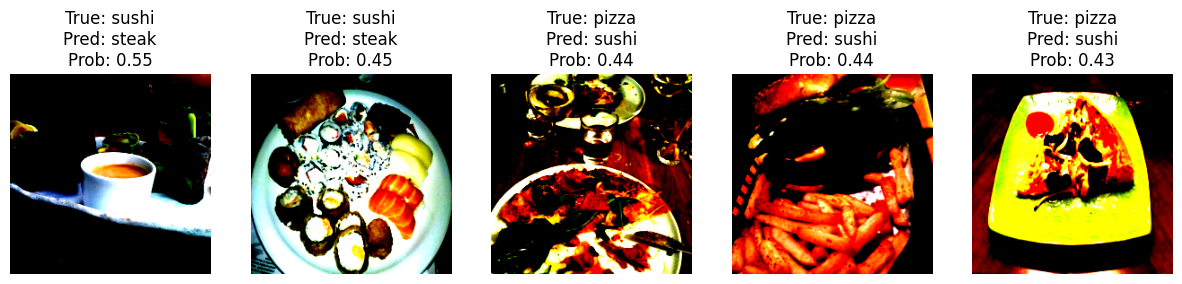

In [30]:
import matplotlib.pyplot as plt
from PIL import Image

top5_wrong = sorted_df.head(5)

plt.figure(figsize=(15,8))
for i, row in enumerate(top5_wrong.itertuples(), 1):
    plt.subplot(1, 5, i)
    plt.imshow(np.transpose(row.sample, (1, 2, 0)))
    plt.axis("off")
    plt.title(f"True: {class_names[row.label]}\nPred: {class_names[row.prediction]}\nProb: {row.pred_prob:.2f}")
plt.show()


## 3. Predict on your own image of pizza/steak/sushi - how does the model go? What happens if you predict on an image that isn't pizza/steak/sushi?
* Here you can get an image from a website like http://www.unsplash.com to try it out or you can upload your own.

In [40]:
# TODO: Get an image of pizza/steak/sushi
import torchvision

custom_image_path = "pizza.jpg"
# Read in custom image
custom_image = torchvision.io.read_image(str(custom_image_path)).type(torch.float32)
custom_image = custom_image / 255.

# Create transform pipleine to resize image
custom_image_transform = transforms.Compose([
    transforms.Resize((64, 64)),
])

# Transform target image
custom_image_transformed = custom_image_transform(custom_image)


# Print out image data
print(f"Custom image tensor:\n{custom_image_transformed}\n")
print(f"Custom image shape: {custom_image_transformed.shape}\n")
print(f"Custom image dtype: {custom_image_transformed.dtype}")

Custom image tensor:
tensor([[[0.0713, 0.0781, 0.0800,  ..., 0.0519, 0.0623, 0.0657],
         [0.0816, 0.0925, 0.0985,  ..., 0.0557, 0.0661, 0.0683],
         [0.3764, 0.4057, 0.4235,  ..., 0.0822, 0.1100, 0.1543],
         ...,
         [0.4269, 0.4121, 0.3997,  ..., 0.0734, 0.0975, 0.1010],
         [0.4346, 0.4172, 0.4348,  ..., 0.0791, 0.1003, 0.1447],
         [0.4282, 0.4048, 0.4296,  ..., 0.1784, 0.1461, 0.2331]],

        [[0.0161, 0.0181, 0.0194,  ..., 0.0275, 0.0230, 0.0218],
         [0.0287, 0.0371, 0.0441,  ..., 0.0300, 0.0241, 0.0250],
         [0.3339, 0.3646, 0.3813,  ..., 0.0616, 0.0874, 0.1657],
         ...,
         [0.4243, 0.4098, 0.3964,  ..., 0.0774, 0.1085, 0.1182],
         [0.4324, 0.4135, 0.4341,  ..., 0.0854, 0.1154, 0.1646],
         [0.4289, 0.4035, 0.4317,  ..., 0.1996, 0.1693, 0.2480]],

        [[0.0026, 0.0018, 0.0017,  ..., 0.0416, 0.0254, 0.0213],
         [0.0116, 0.0151, 0.0173,  ..., 0.0400, 0.0239, 0.0236],
         [0.2756, 0.3066, 0.3147,  ..

In [52]:
model_0.eval()
with torch.inference_mode():
    custom_image_pred = model_0(custom_image_transformed.unsqueeze(0).to(device))
    # Print out prediction logits
    print(f"Prediction logits: {custom_image_pred}")

    # Convert logits -> prediction probabilities (using torch.softmax() for multi-class classification)
    custom_image_pred_probs = torch.softmax(custom_image_pred, dim=1)
    print(f"Prediction probabilities: {custom_image_pred_probs}")

    # Convert prediction probabilities -> prediction labels
    custom_image_pred_label = torch.argmax(custom_image_pred_probs, dim=1)
    print(f"Prediction label: {custom_image_pred_label}")
    custom_image_pred_class = class_names[custom_image_pred_label.cpu()] # put pred label to CPU, otherwise will error
custom_image_pred_class


Prediction logits: tensor([[0.3840, 0.0702, 0.2951]], device='cuda:0')
Prediction probabilities: tensor([[0.3780, 0.2762, 0.3458]], device='cuda:0')
Prediction label: tensor([0], device='cuda:0')


'pizza'

In [54]:
# TODO: Get an image of not pizza/steak/sushi
# TODO: Get an image of pizza/steak/sushi
import torchvision

custom_image_path = "other.jpeg"
# Read in custom image
custom_image = torchvision.io.read_image(str(custom_image_path)).type(torch.float32)
custom_image = custom_image / 255.

# Create transform pipleine to resize image
custom_image_transform = transforms.Compose([
    transforms.Resize((64, 64)),
])

# Transform target image
custom_image_transformed = custom_image_transform(custom_image)


# Print out image data
print(f"Custom image tensor:\n{custom_image_transformed}\n")
print(f"Custom image shape: {custom_image_transformed.shape}\n")
print(f"Custom image dtype: {custom_image_transformed.dtype}")

Custom image tensor:
tensor([[[0.8314, 0.8314, 0.8329,  ..., 0.9169, 0.9183, 0.9148],
         [0.8298, 0.8298, 0.8287,  ..., 0.9415, 0.9404, 0.9357],
         [0.8210, 0.8210, 0.8207,  ..., 0.9420, 0.9320, 0.9246],
         ...,
         [0.7222, 0.7256, 0.7314,  ..., 0.7214, 0.7292, 0.7292],
         [0.7295, 0.7333, 0.7373,  ..., 0.7219, 0.7257, 0.7256],
         [0.7335, 0.7368, 0.7391,  ..., 0.7265, 0.7213, 0.7165]],

        [[0.8588, 0.8588, 0.8603,  ..., 0.9250, 0.9183, 0.9148],
         [0.8572, 0.8572, 0.8562,  ..., 0.9471, 0.9404, 0.9357],
         [0.8484, 0.8484, 0.8481,  ..., 0.9414, 0.9320, 0.9246],
         ...,
         [0.6829, 0.6863, 0.6922,  ..., 0.6861, 0.6939, 0.6939],
         [0.6904, 0.6942, 0.6982,  ..., 0.6866, 0.6904, 0.6903],
         [0.6993, 0.7026, 0.7049,  ..., 0.6912, 0.6860, 0.6812]],

        [[0.9216, 0.9216, 0.9231,  ..., 0.9621, 0.9576, 0.9540],
         [0.9199, 0.9199, 0.9189,  ..., 0.9811, 0.9796, 0.9749],
         [0.9112, 0.9112, 0.9109,  ..

In [55]:
model_0.eval()
with torch.inference_mode():
    custom_image_pred = model_0(custom_image_transformed.unsqueeze(0).to(device))
    # Print out prediction logits
    print(f"Prediction logits: {custom_image_pred}")

    # Convert logits -> prediction probabilities (using torch.softmax() for multi-class classification)
    custom_image_pred_probs = torch.softmax(custom_image_pred, dim=1)
    print(f"Prediction probabilities: {custom_image_pred_probs}")

    # Convert prediction probabilities -> prediction labels
    custom_image_pred_label = torch.argmax(custom_image_pred_probs, dim=1)
    print(f"Prediction label: {custom_image_pred_label}")
    custom_image_pred_class = class_names[custom_image_pred_label.cpu()] # put pred label to CPU, otherwise will error
custom_image_pred_class


Prediction logits: tensor([[0.4185, 0.0262, 0.4065]], device='cuda:0')
Prediction probabilities: tensor([[0.3754, 0.2536, 0.3710]], device='cuda:0')
Prediction label: tensor([0], device='cuda:0')


'pizza'

## 4. Train the model from section 4  in notebook 06 part 3 for longer (10 epochs should do), what happens to the performance?

* See the model in notebook 06 part 3 for reference: https://www.learnpytorch.io/06_pytorch_transfer_learning/#3-getting-a-pretrained-model

In [62]:
# TODO: Recreate a new model
model_1 = torchvision.models.efficientnet_b0(pretrained=True).to(device)
# Freeze all base layers in the "features" section of the model (the feature extractor) by setting requires_grad=False
for param in model_1.features.parameters():
    param.requires_grad = False

# Set the manual seeds
torch.manual_seed(42)
torch.cuda.manual_seed(42)

# Get the length of class_names (one output unit for each class)
output_shape = len(class_names)

# Recreate the classifier layer and seed it to the target device
model_1.classifier = torch.nn.Sequential(
    torch.nn.Dropout(p=0.2, inplace=True),
    torch.nn.Linear(in_features=1280,
                    out_features=output_shape, # same number of output units as our number of classes
                    bias=True)).to(device)

In [63]:
# TODO: Train the model for 10 epochs

# Set the random seeds
torch.manual_seed(42)
torch.cuda.manual_seed(42)

# Start the timer
from timeit import default_timer as timer
start_time = timer()

# Setup training and save the results
model_1_results = engine.train(model=model_1,
                       train_dataloader=train_dataloader,
                       test_dataloader=test_dataloader,
                       optimizer=optimizer,
                       loss_fn=loss_fn,
                       epochs=10,
                       device=device)

# End the timer and print out how long it took
end_time = timer()
print(f"[INFO] Total training time: {end_time-start_time:.3f} seconds")

  0%|          | 0/10 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 1.1222 | train_acc: 0.3477 | test_loss: 1.0999 | test_acc: 0.2689
Epoch: 2 | train_loss: 1.1290 | train_acc: 0.2930 | test_loss: 1.0911 | test_acc: 0.3201
Epoch: 3 | train_loss: 1.1166 | train_acc: 0.2656 | test_loss: 1.0942 | test_acc: 0.3201
Epoch: 4 | train_loss: 1.1160 | train_acc: 0.2734 | test_loss: 1.0968 | test_acc: 0.2888
Epoch: 5 | train_loss: 1.1286 | train_acc: 0.2812 | test_loss: 1.1010 | test_acc: 0.2680
Epoch: 6 | train_loss: 1.1389 | train_acc: 0.2969 | test_loss: 1.0943 | test_acc: 0.2992
Epoch: 7 | train_loss: 1.1383 | train_acc: 0.2734 | test_loss: 1.0992 | test_acc: 0.2784
Epoch: 8 | train_loss: 1.1312 | train_acc: 0.2930 | test_loss: 1.1033 | test_acc: 0.2888
Epoch: 9 | train_loss: 1.1150 | train_acc: 0.3906 | test_loss: 1.1062 | test_acc: 0.3201
Epoch: 10 | train_loss: 1.1422 | train_acc: 0.2734 | test_loss: 1.1037 | test_acc: 0.3191
[INFO] Total training time: 17.493 seconds


## 5. Train the model from section 4 above with more data, say 20% of the images from Food101 of Pizza, Steak and Sushi images.
* You can find the [20% Pizza, Steak, Sushi dataset](https://github.com/mrdbourke/pytorch-deep-learning/blob/main/data/pizza_steak_sushi_20_percent.zip) on the course GitHub. It was created with the notebook [`extras/04_custom_data_creation.ipynb`](https://github.com/mrdbourke/pytorch-deep-learning/blob/main/extras/04_custom_data_creation.ipynb).


### Get 20% data

In [64]:
import os
import requests
import zipfile

from pathlib import Path

# Setup path to data folder
data_path = Path("data/")
image_path = data_path / "pizza_steak_sushi_20_percent"
image_data_zip_path = "pizza_steak_sushi_20_percent.zip"

# If the image folder doesn't exist, download it and prepare it...
if image_path.is_dir():
    print(f"{image_path} directory exists.")
else:
    print(f"Did not find {image_path} directory, creating one...")
    image_path.mkdir(parents=True, exist_ok=True)

    # Download pizza, steak, sushi data
    with open(data_path / image_data_zip_path, "wb") as f:
        request = requests.get("https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi_20_percent.zip")
        print("Downloading pizza, steak, sushi data...")
        f.write(request.content)

    # Unzip pizza, steak, sushi data
    with zipfile.ZipFile(data_path / image_data_zip_path, "r") as zip_ref:
        print("Unzipping pizza, steak, sushi 20% data...")
        zip_ref.extractall(image_path)

    # Remove .zip file
    os.remove(data_path / image_data_zip_path)

# Setup Dirs
train_dir_20_percent = image_path / "train"
test_dir_20_percent = image_path / "test"

train_dir_20_percent, test_dir_20_percent

Did not find data/pizza_steak_sushi_20_percent directory, creating one...
Unzipping pizza, steak, sushi 20% data...


(PosixPath('data/pizza_steak_sushi_20_percent/train'),
 PosixPath('data/pizza_steak_sushi_20_percent/test'))

### Create DataLoaders

In [65]:
# Create a transforms pipeline
simple_transform = transforms.Compose([
    transforms.Resize((224, 224)), # 1. Reshape all images to 224x224 (though some models may require different sizes)
    transforms.ToTensor(), # 2. Turn image values to between 0 & 1
    transforms.Normalize(mean=[0.485, 0.456, 0.406], # 3. A mean of [0.485, 0.456, 0.406] (across each colour channel)
                         std=[0.229, 0.224, 0.225]) # 4. A standard deviation of [0.229, 0.224, 0.225] (across each colour channel),
])

In [66]:
# Create training and testing DataLoader's as well as get a list of class names
train_dataloader_20_percent, test_dataloader_20_percent, class_names = data_setup.create_dataloaders(train_dir=train_dir_20_percent,
                                                                                                     test_dir=test_dir_20_percent,
                                                                                                     transform=simple_transform, # resize, convert images to between 0 & 1 and normalize them
                                                                                                     batch_size=32) # set mini-batch size to 32

train_dataloader_20_percent, test_dataloader_20_percent, class_names

(<torch.utils.data.dataloader.DataLoader at 0x7d4c67a1d310>,
 ['pizza', 'steak', 'sushi'])

### Get a pretrained model

In [67]:
# TODO
# TODO: Recreate a new model
model_2 = torchvision.models.efficientnet_b0(pretrained=True).to(device)
# Freeze all base layers in the "features" section of the model (the feature extractor) by setting requires_grad=False
for param in model_2.features.parameters():
    param.requires_grad = False

# Set the manual seeds
torch.manual_seed(42)
torch.cuda.manual_seed(42)

# Get the length of class_names (one output unit for each class)
output_shape = len(class_names)

# Recreate the classifier layer and seed it to the target device
model_2.classifier = torch.nn.Sequential(
    torch.nn.Dropout(p=0.2, inplace=True),
    torch.nn.Linear(in_features=1280,
                    out_features=output_shape, # same number of output units as our number of classes
                    bias=True)).to(device)

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


### Train a model with 20% of the data

In [72]:
# TODO

# Set the random seeds
torch.manual_seed(42)
torch.cuda.manual_seed(42)

# Start the timer
from timeit import default_timer as timer
start_time = timer()

# Setup training and save the results
model_2_results = engine.train(model=model_2,
                       train_dataloader=train_dataloader_20_percent,
                       test_dataloader=test_dataloader_20_percent,
                       optimizer=optimizer,
                       loss_fn=loss_fn,
                       epochs=5,
                       device=device)

# End the timer and print out how long it took
end_time = timer()
print(f"[INFO] Total training time: {end_time-start_time:.3f} seconds")
model_2_results

  0%|          | 0/5 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 1.1168 | train_acc: 0.3833 | test_loss: 1.0873 | test_acc: 0.3750
Epoch: 2 | train_loss: 1.1326 | train_acc: 0.3271 | test_loss: 1.0923 | test_acc: 0.3875
Epoch: 3 | train_loss: 1.1222 | train_acc: 0.3000 | test_loss: 1.0875 | test_acc: 0.3761
Epoch: 4 | train_loss: 1.1153 | train_acc: 0.3875 | test_loss: 1.0936 | test_acc: 0.3756
Epoch: 5 | train_loss: 1.1264 | train_acc: 0.3250 | test_loss: 1.0872 | test_acc: 0.3903
[INFO] Total training time: 16.826 seconds


{'train_loss': [1.1167707602183023,
  1.132634703318278,
  1.122189744313558,
  1.1152510007222494,
  1.126431655883789],
 'train_acc': [0.38333333333333336, 0.32708333333333334, 0.3, 0.3875, 0.325],
 'test_loss': [1.0873226165771483,
  1.0923284053802491,
  1.0874799251556397,
  1.0935713529586792,
  1.0872125387191773],
 'test_acc': [0.375,
  0.3875,
  0.3761363636363636,
  0.37556818181818186,
  0.39034090909090907]}

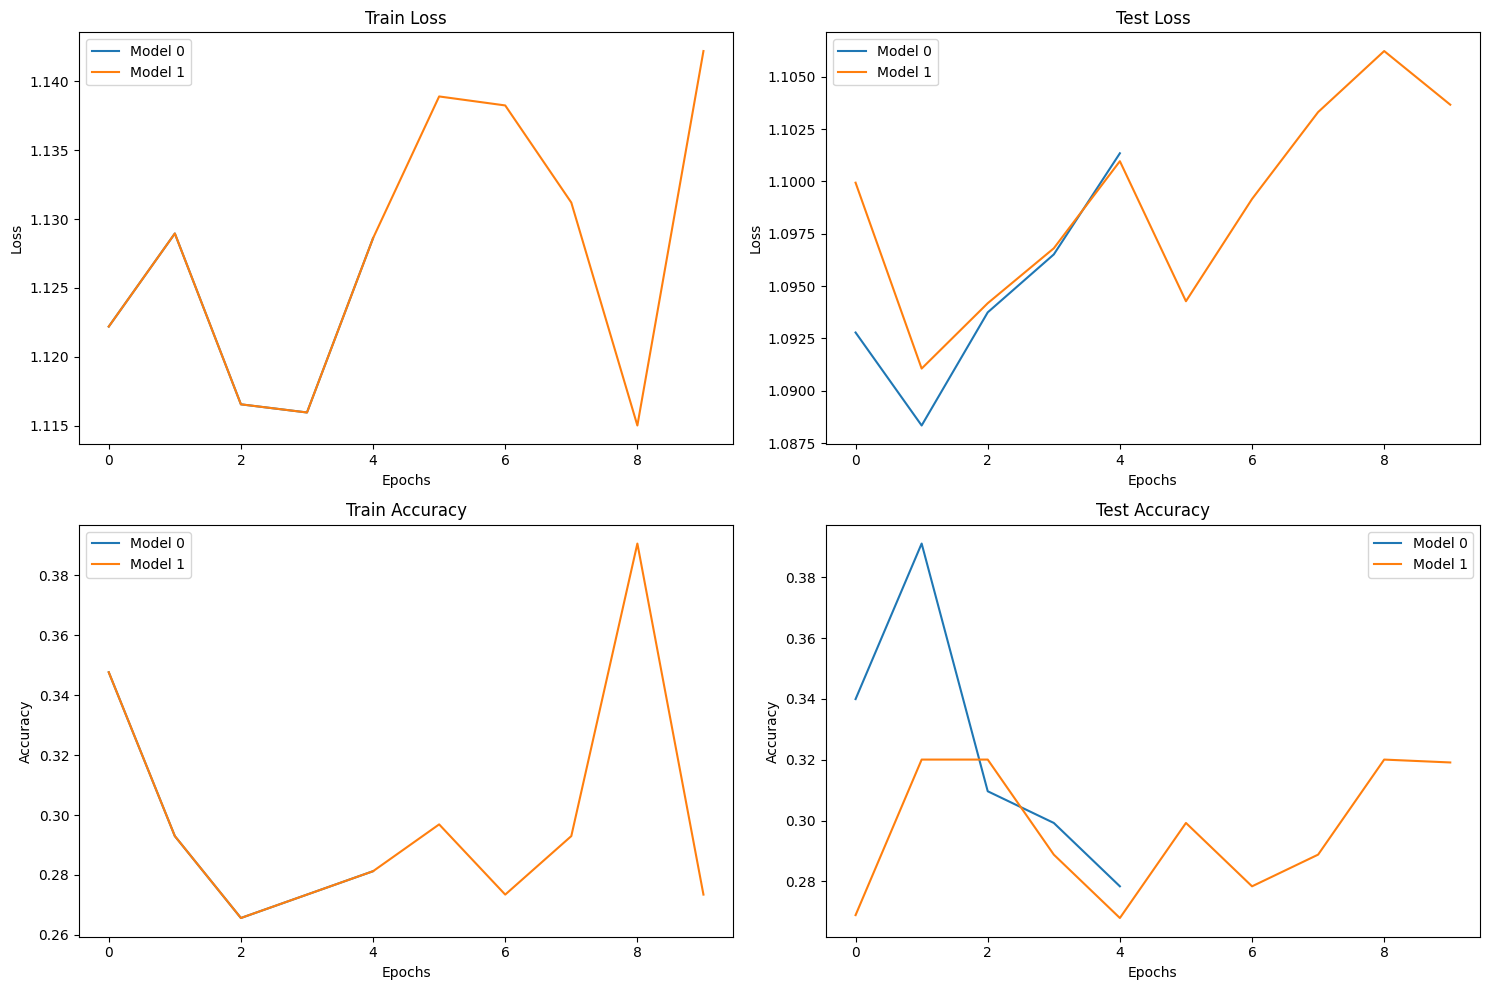

In [78]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,10))

# ---- Train Loss ----
plt.subplot(2, 2, 1)
epochs_0 = range(len(model_0_results["train_loss"]))  # 0..9
epochs_1 = range(len(model_1_results["train_loss"]))  # 0..4
plt.plot(epochs_0, model_0_results["train_loss"], label="Model 0")
plt.plot(epochs_1, model_1_results["train_loss"], label="Model 1")
plt.title("Train Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

# ---- Test Loss ----
plt.subplot(2, 2, 2)
plt.plot(range(len(model_0_results["test_loss"])), model_0_results["test_loss"], label="Model 0")
plt.plot(range(len(model_1_results["test_loss"])), model_1_results["test_loss"], label="Model 1")
plt.title("Test Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

# ---- Train Accuracy ----
plt.subplot(2, 2, 3)
plt.plot(range(len(model_0_results["train_acc"])), model_0_results["train_acc"], label="Model 0")
plt.plot(range(len(model_1_results["train_acc"])), model_1_results["train_acc"], label="Model 1")
plt.title("Train Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

# ---- Test Accuracy ----
plt.subplot(2, 2, 4)
plt.plot(range(len(model_0_results["test_acc"])), model_0_results["test_acc"], label="Model 0")
plt.plot(range(len(model_1_results["test_acc"])), model_1_results["test_acc"], label="Model 1")
plt.title("Test Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()


## 6. Try a different model from [`torchvision.models`](https://pytorch.org/vision/stable/models.html) on the Pizza, Steak, Sushi data, how does this model perform?
* You'll have to change the size of the classifier layer to suit our problem.
* You may want to try an EfficientNet with a higher number than our B0, perhaps `torchvision.models.efficientnet_b2()`?
  * **Note:** Depending on the model you use you will have to prepare/transform the data in a certain way.

In [82]:
model_3 = torchvision.models.efficientnet_b2(pretrained=True).to(device)
# Freeze all base layers in the "features" section of the model (the feature extractor) by setting requires_grad=False
for param in model_3.features.parameters():
    param.requires_grad = False

# Set the manual seeds
torch.manual_seed(42)
torch.cuda.manual_seed(42)

# Get the length of class_names (one output unit for each class)
output_shape = len(class_names)

# Recreate the classifier layer and seed it to the target device
model_3.classifier = torch.nn.Sequential(
    torch.nn.Dropout(p=0.2, inplace=True),
    torch.nn.Linear(in_features=1408,
                    out_features=output_shape, # same number of output units as our number of classes
                    bias=True)).to(device)


In [83]:
# Set the random seeds
torch.manual_seed(42)
torch.cuda.manual_seed(42)

# Start the timer
from timeit import default_timer as timer
start_time = timer()

# Setup training and save the results
model_3_results = engine.train(model=model_3,
                       train_dataloader=train_dataloader_20_percent,
                       test_dataloader=test_dataloader_20_percent,
                       optimizer=optimizer,
                       loss_fn=loss_fn,
                       epochs=5,
                       device=device)

# End the timer and print out how long it took
end_time = timer()
print(f"[INFO] Total training time: {end_time-start_time:.3f} seconds")
model_3_results

  0%|          | 0/5 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 1.1406 | train_acc: 0.2583 | test_loss: 1.0984 | test_acc: 0.3710
Epoch: 2 | train_loss: 1.1227 | train_acc: 0.3292 | test_loss: 1.0852 | test_acc: 0.3744
Epoch: 3 | train_loss: 1.1313 | train_acc: 0.3000 | test_loss: 1.0815 | test_acc: 0.3864
Epoch: 4 | train_loss: 1.1163 | train_acc: 0.2854 | test_loss: 1.0779 | test_acc: 0.3926
Epoch: 5 | train_loss: 1.1409 | train_acc: 0.2875 | test_loss: 1.0780 | test_acc: 0.4085
[INFO] Total training time: 16.993 seconds


{'train_loss': [1.1406468550364177,
  1.122737185160319,
  1.131320548057556,
  1.1163057724634806,
  1.140896733601888],
 'train_acc': [0.25833333333333336,
  0.32916666666666666,
  0.3,
  0.28541666666666665,
  0.2875],
 'test_loss': [1.0983508825302124,
  1.0852266192436217,
  1.0814777970314027,
  1.0779083013534545,
  1.0779525876045226],
 'test_acc': [0.3710227272727272,
  0.37443181818181814,
  0.38636363636363635,
  0.39261363636363633,
  0.40852272727272726]}

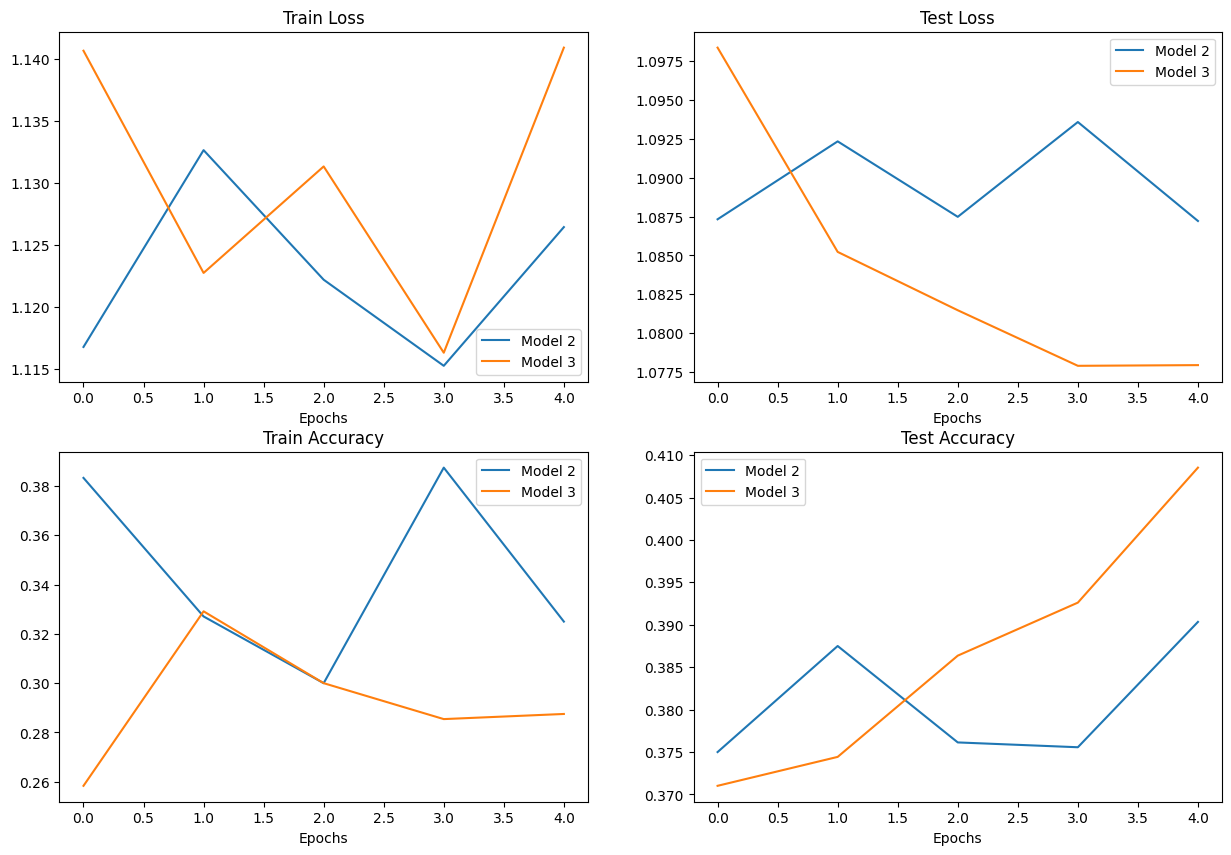

In [87]:
# Setup a plot
plt.figure(figsize=(15, 10))

# Get number of epochs
epochs = range(len(model_2_results['test_acc']))

# Plot train loss
plt.subplot(2, 2, 1)
plt.plot(epochs, model_2_results["train_loss"], label="Model 2")
plt.plot(epochs, model_3_results["train_loss"], label="Model 3")
plt.title("Train Loss")
plt.xlabel("Epochs")
plt.legend()

# Plot test loss
plt.subplot(2, 2, 2)
plt.plot(epochs, model_2_results["test_loss"], label="Model 2")
plt.plot(epochs, model_3_results["test_loss"], label="Model 3")
plt.title("Test Loss")
plt.xlabel("Epochs")
plt.legend()

# Plot train accuracy
plt.subplot(2, 2, 3)
plt.plot(epochs, model_2_results["train_acc"], label="Model 2")
plt.plot(epochs, model_3_results["train_acc"], label="Model 3")
plt.title("Train Accuracy")
plt.xlabel("Epochs")
plt.legend()

# Plot test accuracy
plt.subplot(2, 2, 4)
plt.plot(epochs, model_2_results["test_acc"], label="Model 2")
plt.plot(epochs, model_3_results["test_acc"], label="Model 3")
plt.title("Test Accuracy")
plt.xlabel("Epochs")
plt.legend();


In [ ]:
Model 3 appears to perform better.